<a href="https://colab.research.google.com/github/vinaekalaylani/pengolahan-citra-midterm/blob/main/uts_pengolahan_citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Upload minimal 2 image files:")
uploaded = files.upload()

filenames = list(uploaded.keys())

if len(filenames) < 2:
  print("Please upload at least 2 images.")
else:
  img1 = cv2.imread(filenames[0])
  img2 = cv2.imread(filenames[1])

  if img1 is None or img2 is None:
    print("Error: Unable to read one or both images.")
  else:
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,5))

    plt.subplot(2,2,1)
    plt.imshow(img1_rgb)
    plt.title("Image 1 (RGB)")
    plt.axis('off')

    plt.subplot(2,2,2)
    plt.imshow(img2_rgb)
    plt.title("Image 2 (RGB)")
    plt.axis('off')

    plt.show()

Upload minimal 2 image files:


Saving buttercup-1.jpg to buttercup-1 (4).jpg
Please upload at least 2 images.


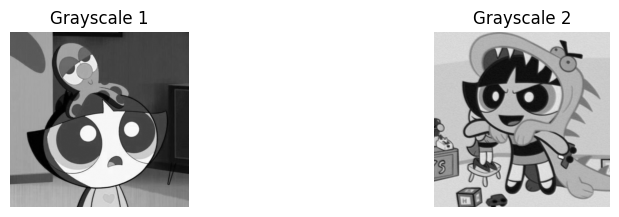

In [ ]:
gray1 = cv2.cvtColor(img1_rgb, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2_rgb, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10,5))

# Image 1
plt.subplot(2,2,1)
plt.imshow(gray1, cmap='gray')
plt.title("Grayscale 1")
plt.axis('off')

# Image 2
plt.subplot(2,2,2)
plt.imshow(gray2, cmap='gray')
plt.title("Grayscale 2")
plt.axis('off')

plt.show()

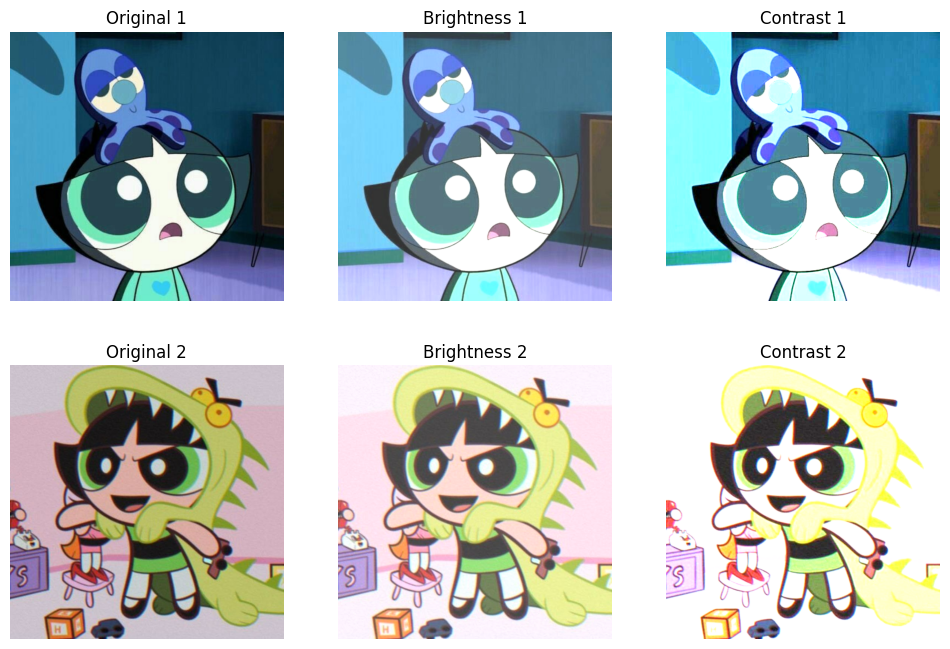

In [ ]:
bright1 = cv2.convertScaleAbs(img1, alpha=1, beta=50)
contrast1 = cv2.convertScaleAbs(img1, alpha=2, beta=0)

bright2 = cv2.convertScaleAbs(img2, alpha=1, beta=50)
contrast2 = cv2.convertScaleAbs(img2, alpha=2, beta=0)

plt.figure(figsize=(12,8))

# Image 1
plt.subplot(2,3,1)
plt.imshow(img1_rgb)
plt.title("Original 1")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(cv2.cvtColor(bright1, cv2.COLOR_BGR2RGB))
plt.title("Brightness 1")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(cv2.cvtColor(contrast1, cv2.COLOR_BGR2RGB))
plt.title("Contrast 1")
plt.axis('off')

# Image 2
plt.subplot(2,3,4)
plt.imshow(img2_rgb)
plt.title("Original 2")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(cv2.cvtColor(bright2, cv2.COLOR_BGR2RGB))
plt.title("Brightness 2")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(cv2.cvtColor(contrast2, cv2.COLOR_BGR2RGB))
plt.title("Contrast 2")
plt.axis('off')

plt.show()

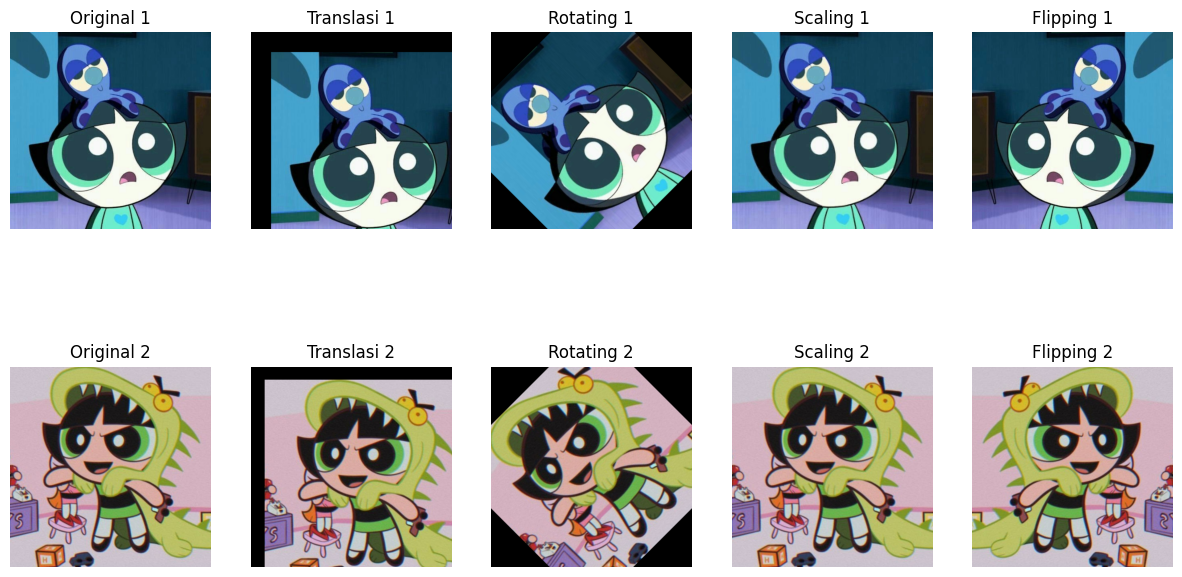

In [ ]:
rows1, cols1 = img1.shape[:2]
rows2, cols2 = img2.shape[:2]

M1 = np.float32([[1, 0, 50], [0, 1, 50]])
M2 = np.float32([[1, 0, 50], [0, 1, 50]])

trans1 = cv2.warpAffine(img1, M1, (cols1, rows1))
trans2 = cv2.warpAffine(img2, M2, (cols2, rows2))

M_rot1 = cv2.getRotationMatrix2D((cols1/2, rows1/2), 45, 1)
M_rot2 = cv2.getRotationMatrix2D((cols2/2, rows2/2), 45, 1)

rot1 = cv2.warpAffine(img1, M_rot1, (cols1, rows1))
rot2 = cv2.warpAffine(img2, M_rot2, (cols2, rows2))

scale1 = cv2.resize(img1, None, fx=0.5, fy=0.5)
scale2 = cv2.resize(img2, None, fx=0.5, fy=0.5)

flip1 = cv2.flip(img1, 1)
flip2 = cv2.flip(img2, 1)

plt.figure(figsize=(15,8))

# Image 1
plt.subplot(2,5,1)
plt.imshow(img1_rgb)
plt.title("Original 1")
plt.axis('off')

plt.subplot(2,5,2)
plt.imshow(cv2.cvtColor(trans1, cv2.COLOR_BGR2RGB))
plt.title("Translasi 1")
plt.axis('off')

plt.subplot(2,5,3)
plt.imshow(cv2.cvtColor(rot1, cv2.COLOR_BGR2RGB))
plt.title("Rotating 1")
plt.axis('off')

plt.subplot(2,5,4)
plt.imshow(cv2.cvtColor(scale1, cv2.COLOR_BGR2RGB))
plt.title("Scaling 1")
plt.axis('off')

plt.subplot(2,5,5)
plt.imshow(cv2.cvtColor(flip1, cv2.COLOR_BGR2RGB))
plt.title("Flipping 1")
plt.axis('off')

# Image 2
plt.subplot(2,5,6)
plt.imshow(img2_rgb)
plt.title("Original 2")
plt.axis('off')

plt.subplot(2,5,7)
plt.imshow(cv2.cvtColor(trans2, cv2.COLOR_BGR2RGB))
plt.title("Translasi 2")
plt.axis('off')

plt.subplot(2,5,8)
plt.imshow(cv2.cvtColor(rot2, cv2.COLOR_BGR2RGB))
plt.title("Rotating 2")
plt.axis('off')

plt.subplot(2,5,9)
plt.imshow(cv2.cvtColor(scale2, cv2.COLOR_BGR2RGB))
plt.title("Scaling 2")
plt.axis('off')

plt.subplot(2,5,10)
plt.imshow(cv2.cvtColor(flip2, cv2.COLOR_BGR2RGB))
plt.title("Flipping 2")
plt.axis('off')

plt.show()

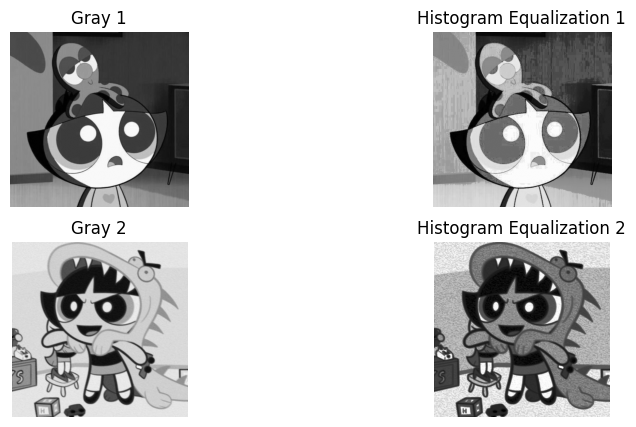

In [ ]:
hist1 = cv2.equalizeHist(gray1)
hist2 = cv2.equalizeHist(gray2)

plt.figure(figsize=(10,5))

# Image 1
plt.subplot(2,2,1)
plt.imshow(gray1, cmap='gray')
plt.title("Gray 1")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(hist1, cmap='gray')
plt.title("Histogram Equalization 1")
plt.axis('off')

# Image 2
plt.subplot(2,2,3)
plt.imshow(gray2, cmap='gray')
plt.title("Gray 2")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(hist2, cmap='gray')
plt.title("Histogram Equalization 2")
plt.axis('off')

plt.show()

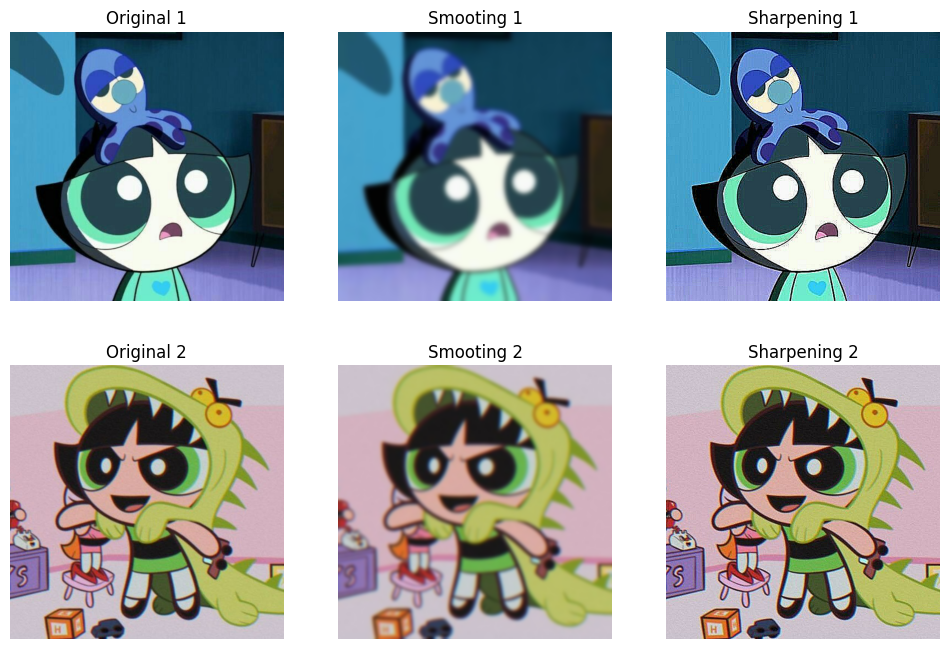

In [ ]:
blur1 = cv2.GaussianBlur(img1, (25,25), 0)
blur2 = cv2.GaussianBlur(img2, (25,25), 0)

kernel = np.array([[0,-2,0],
                   [-2,9,-2],
                   [0,-2,0]])

sharp1 = cv2.filter2D(img1, -1, kernel)
sharp2 = cv2.filter2D(img2, -1, kernel)

plt.figure(figsize=(12,8))

# Image 1
plt.subplot(2,3,1)
plt.imshow(img1_rgb)
plt.title("Original 1")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(cv2.cvtColor(blur1, cv2.COLOR_BGR2RGB))
plt.title("Smooting 1")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(cv2.cvtColor(sharp1, cv2.COLOR_BGR2RGB))
plt.title("Sharpening 1")
plt.axis('off')

# Image 2
plt.subplot(2,3,4)
plt.imshow(img2_rgb)
plt.title("Original 2")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(cv2.cvtColor(blur2, cv2.COLOR_BGR2RGB))
plt.title("Smooting 2")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(cv2.cvtColor(sharp2, cv2.COLOR_BGR2RGB))
plt.title("Sharpening 2")
plt.axis('off')

plt.show()